# Plot H and H Growth Curves
March 6, 2024

Check the matrix H and the locations of DG1 with different alpha values

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_replicate1_rg1_alpha_vst_config
from src.dynamic_config_alpha import create_dynamic_alpha_config
from src.model import Model

def plot_H(alpha, replicate):
    gene_name = 'CLB2'
    posteriors_path = f'data/2019_cloccs_fits/yl_2019_replicate{replicate}/posteriors.txt'

    config = create_dynamic_alpha_config(alpha, replicate)
    model = Model(config, gene_name)
    #chromatin_model = ChromatinModel(config)
    #chromatin_model.load_mnase_gene(gene_name)
    #chromatin_model.create_deconvolution_bins()
    #chromatin_model.setup_deconv_model()

    model.plot_H()

    return model

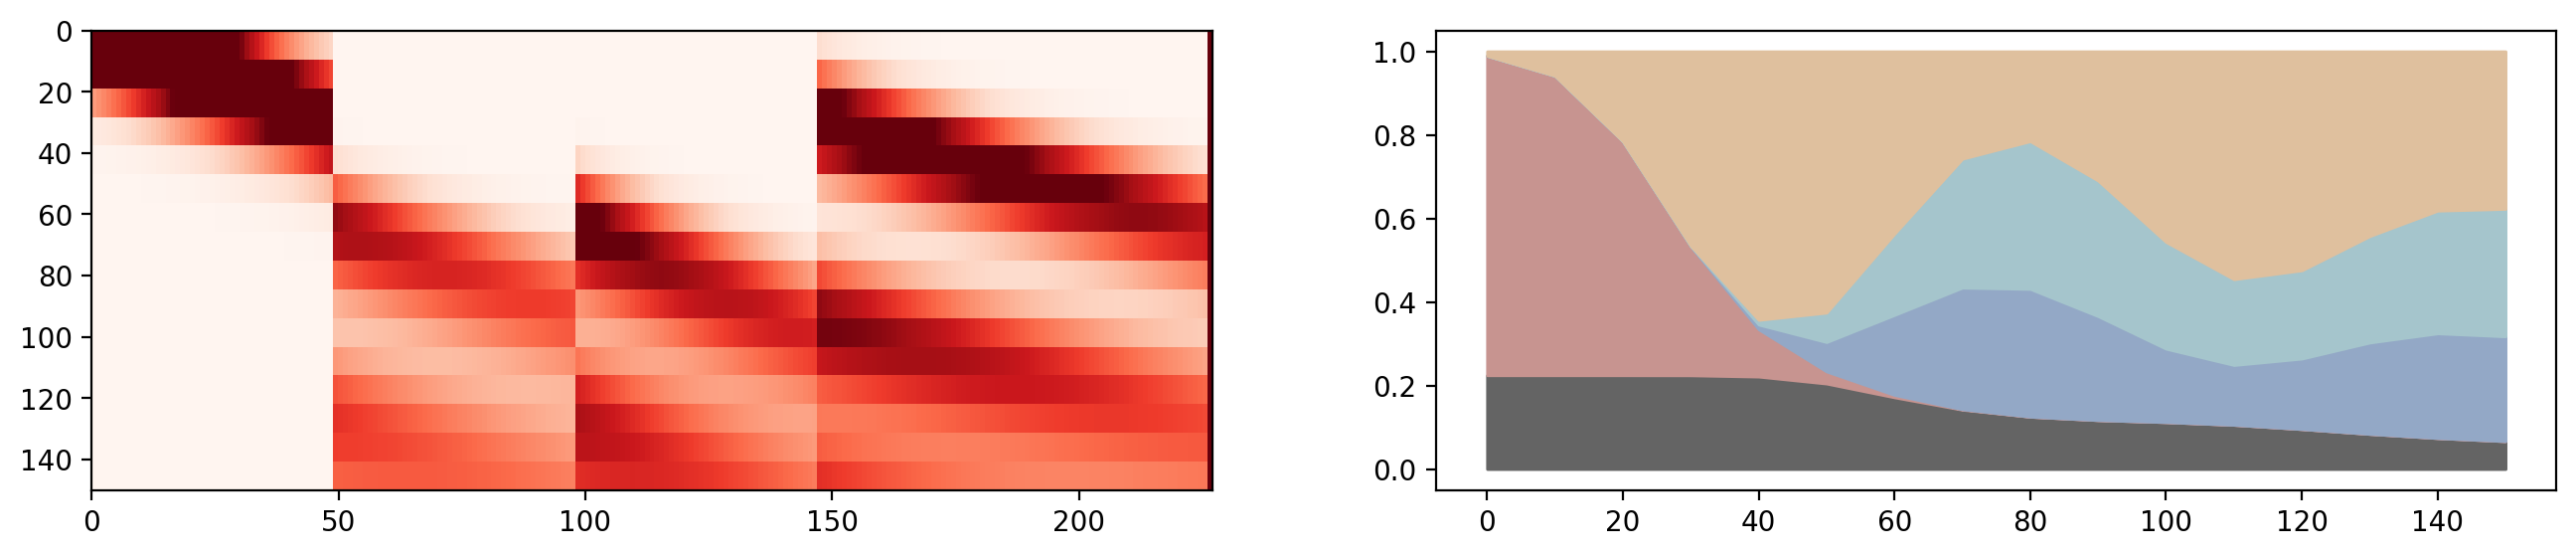

In [3]:
# This includes the expected daughter-specific delay
plot_H(alpha=28, replicate=1)

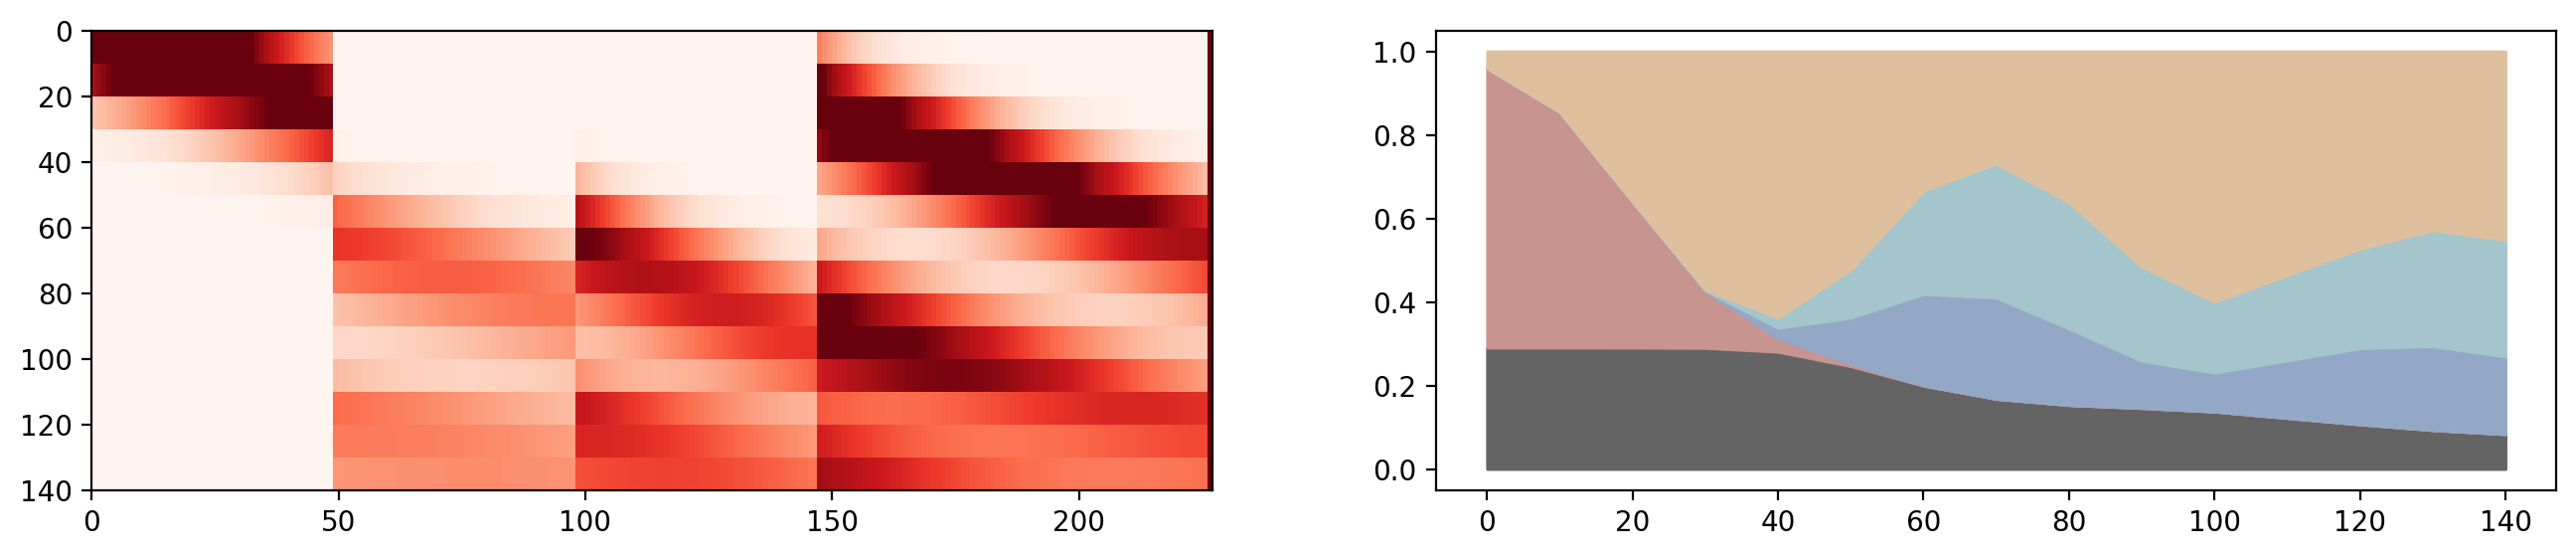

In [4]:
plot_H(alpha=19, replicate=2)

In [5]:
from src.create_models_S import ModelCreation as ModelCreationS
from src.config import Config, read_yl_vst_data_rep

# We can create a model that includes S

replicate = 1

alpha = 28

posteriors_path = f'data/2019_cloccs_fits/yl_2019_replicate{replicate}/posteriors.txt'
output_path = 'models/yl_cell_cycle/wt1_s_rg1.28.label'

model_creator = ModelCreationS(posteriors_path, output_path)
model_creator.alpha = alpha
model_creator.create_model()

config = Config(wt1=read_yl_vst_data_rep(replicate), model_wt1_file=output_path, 
                name=f'Replicate 1 S, $\\alpha$={alpha}', 
                replicate=1, alpha=alpha)


Created model and saved to file: models/yl_cell_cycle/wt1_s_rg1.28.label


In [6]:
model = Model(config, 'CLN2')

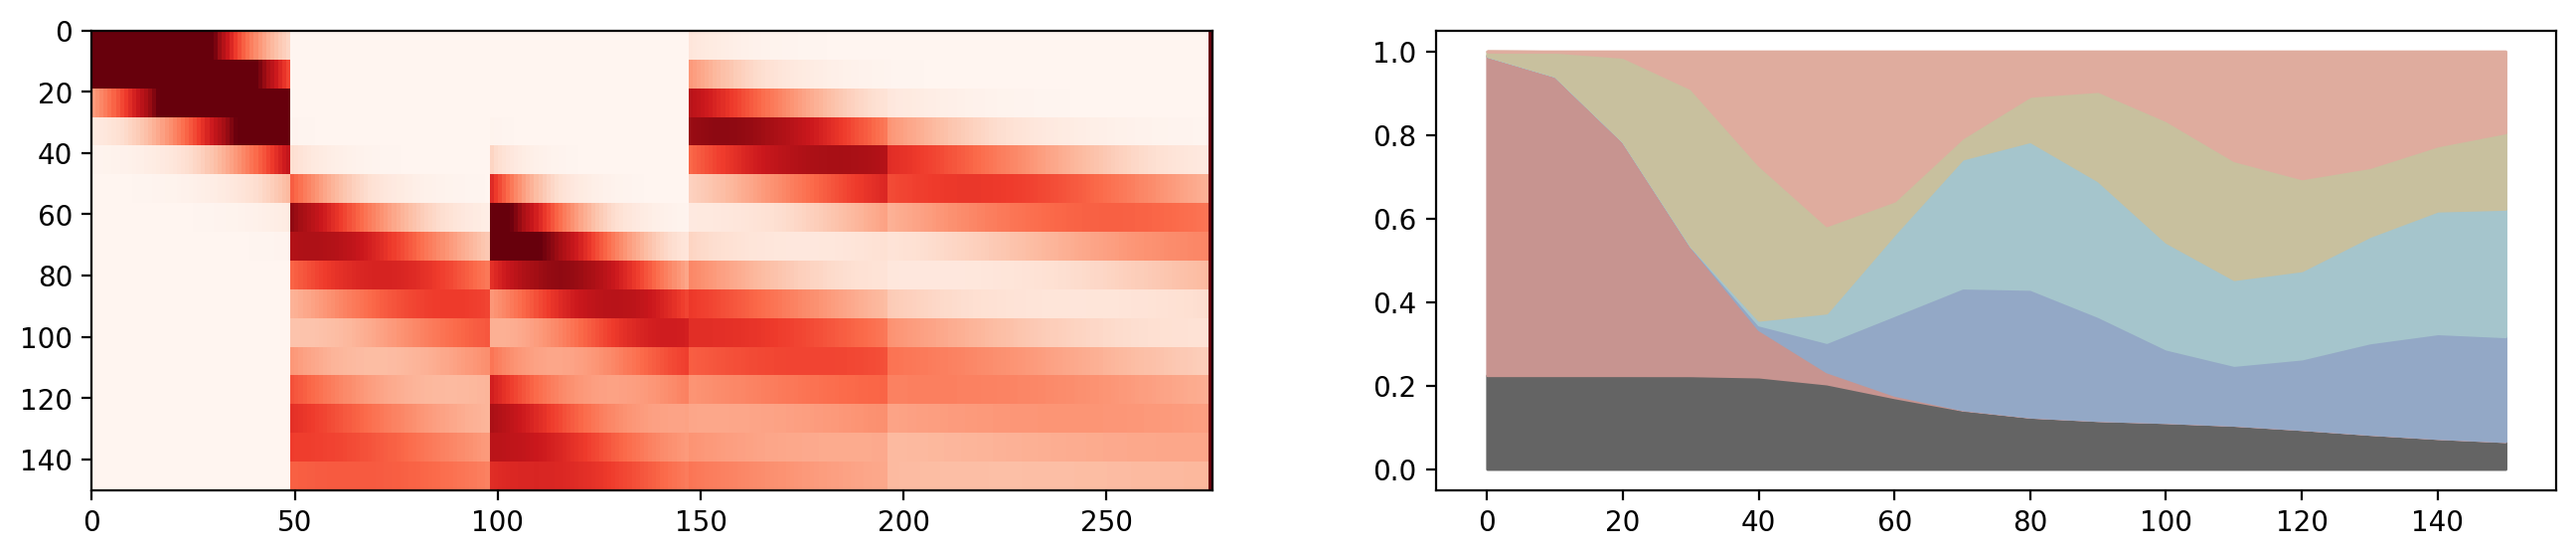

In [7]:
model.plot_H()

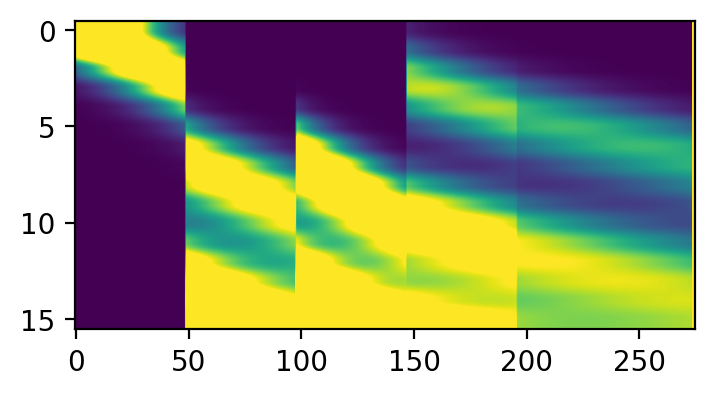

In [34]:
from src.estimate_dna_content import calcH_unnormalized

H, intervals = calcH_unnormalized(model.config.intervals_wt1, model.config.WT1_TIMEPOINTS)

plt.figure(figsize=(4, 2))
plt.imshow(H[:, :], vmax=10, aspect='auto')

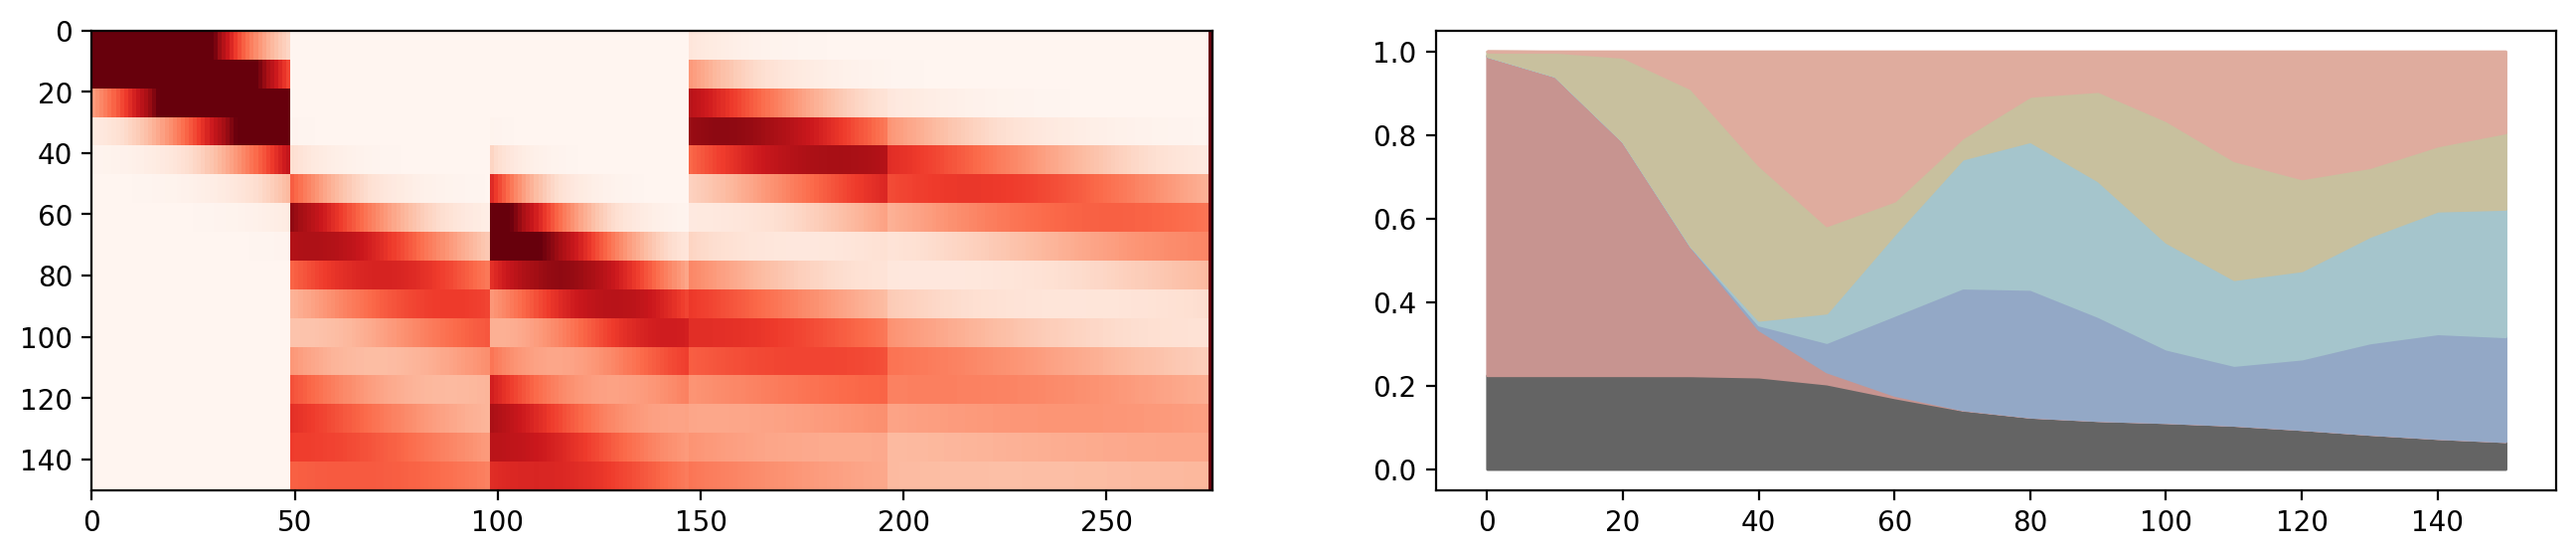

In [35]:
model.plot_H()

In [36]:
from src.cloccs_like_calculator import LikeCalculator

calculator = LikeCalculator(config)


In [38]:
calculator.create_estimated_flow_fit()

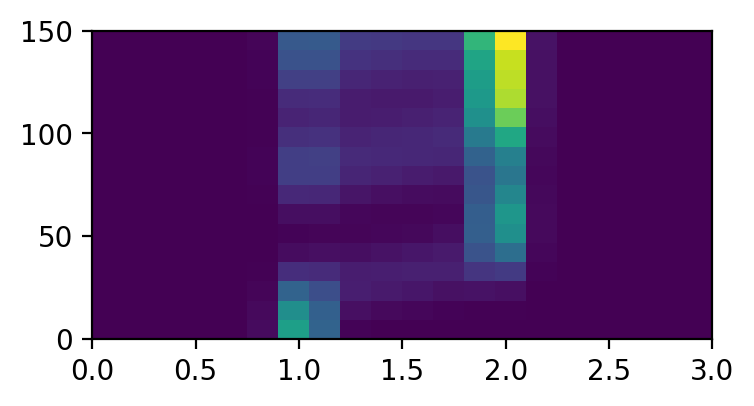

In [43]:
calculator.plot_estimated_flow_fit()

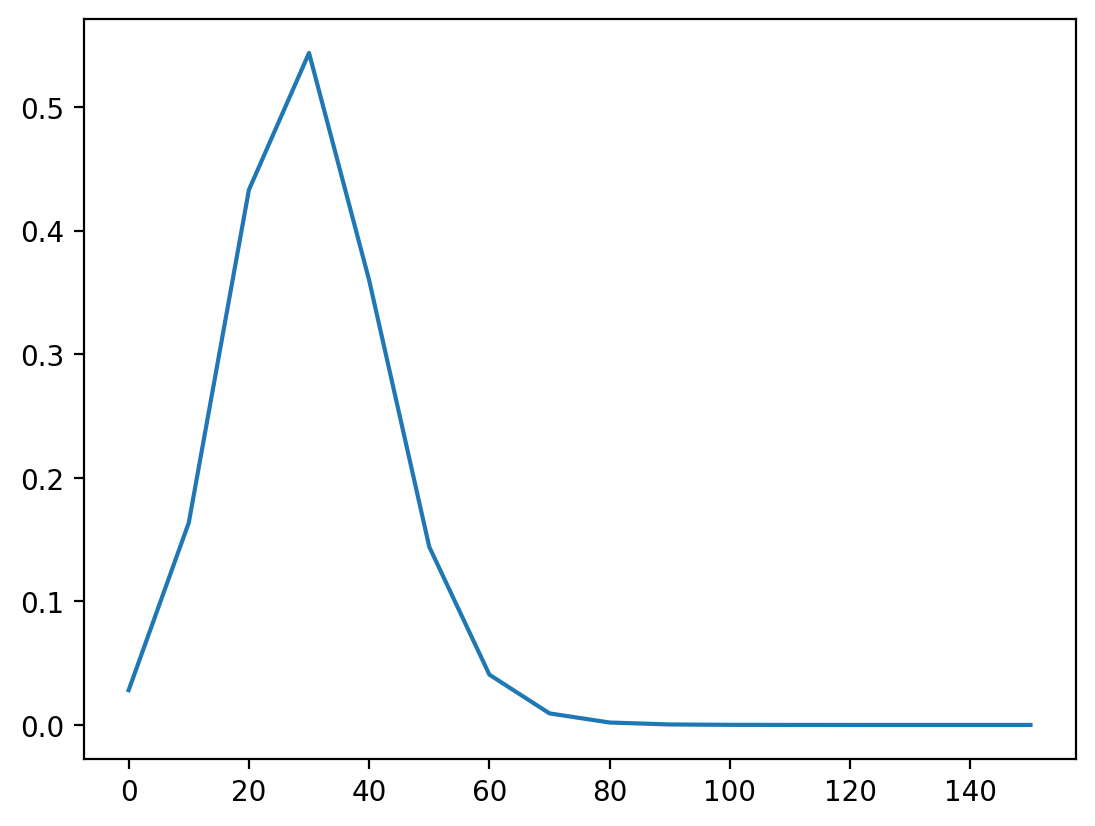

In [19]:
plt.plot(timepoints, s_dna_contents)

In [61]:
c = 1
mean_g, sd_g = calculator.get_position_distribution_parameters(g, r, time)

times = calculator.timepoints

dna_content_s = np.zeros(len(times))
MAX_GENERATIONS = 3
MAX_CELL_CYCLES = 3

for i in range(len(times)):
    time = times[i]
    
    current_dna_s = 0

    for r in range(0, MAX_GENERATIONS + 1):
        for g in range(0, r + 1):
            for c in range(0, MAX_CELL_CYCLES):
    
                current_dna_s += calculator.compute_dna_content_s(time, g, r, c)

    dna_content_s[i] = current_dna_s


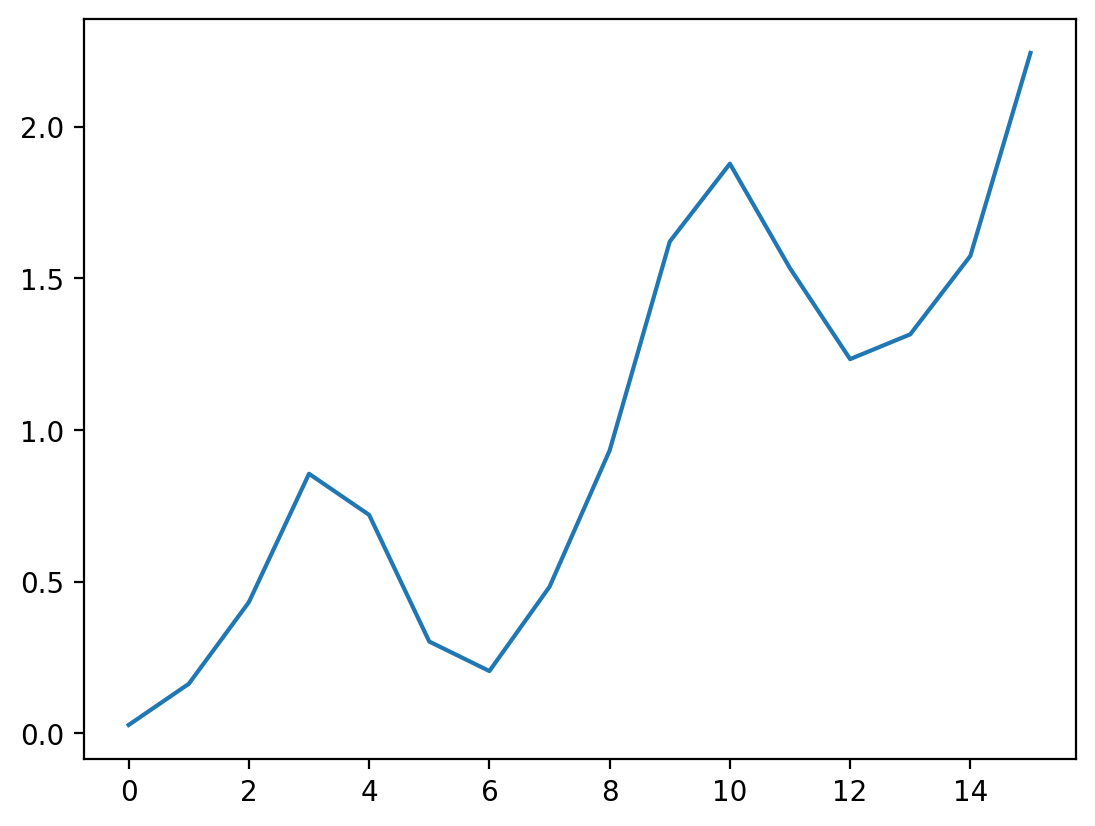

In [62]:
plt.plot(dna_content_s)

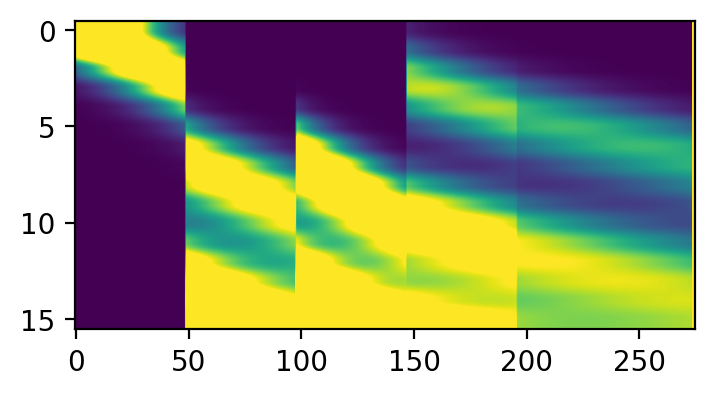

In [45]:
from src.estimate_dna_content import calcH_unnormalized

H, intervals = calcH_unnormalized(model.config.intervals_wt1, model.config.WT1_TIMEPOINTS)

plt.figure(figsize=(4, 2))
plt.imshow(H[:, :], vmax=10, aspect='auto')

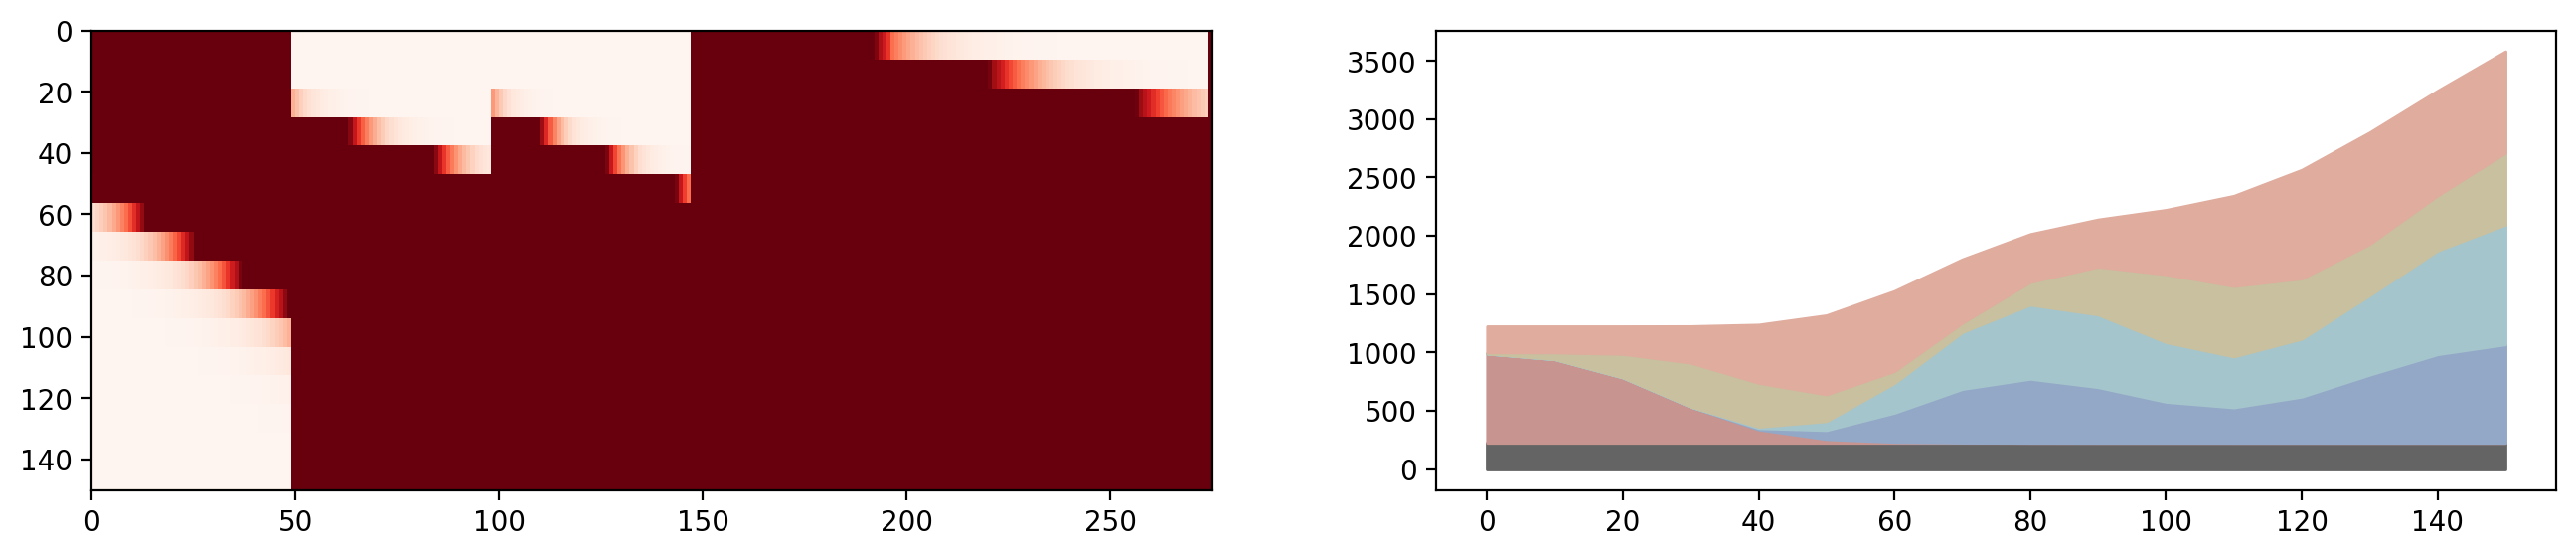

In [63]:
model.plot_H(H)